### Biblioteki

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Wczytanie CSV

In [3]:
product = pd.read_csv("product.csv")

In [4]:
product.head()

,Product_ID,Product_Name,Category,Price_USD,Quantity_Sold,Total_Sales_USD,Order_Date,Customer_City
0,1001,Lipstick,Beauty,26,7,182,2025-01-24,Karachi
1,1002,Jacket,Fashion,254,6,1524,2026-04-01,Peshawar
2,1003,Gym Gloves,Sports,30,10,300,2025-11-05,Peshawar
3,1004,History Book,Books,45,6,270,2026-01-05,Lahore
4,1005,Tennis Ball,Sports,401,1,401,2025-11-28,Quetta


In [5]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Product_ID       1000 non-null   int64 
 1   Product_Name     1000 non-null   object
 2   Category         1000 non-null   object
 3   Price_USD        1000 non-null   int64 
 4   Quantity_Sold    1000 non-null   int64 
 5   Total_Sales_USD  1000 non-null   int64 
 6   Order_Date       1000 non-null   object
 7   Customer_City    1000 non-null   object
dtypes: int64(4), object(4)
memory usage: 62.6+ KB


In [6]:
product.isnull().sum()

Product_ID         0
Product_Name       0
Category           0
Price_USD          0
Quantity_Sold      0
Total_Sales_USD    0
Order_Date         0
Customer_City      0
dtype: int64

In [7]:
product["Order_Date"] = pd.to_datetime(product["Order_Date"])
product.pop("Product_ID")
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Product_Name     1000 non-null   object        
 1   Category         1000 non-null   object        
 2   Price_USD        1000 non-null   int64         
 3   Quantity_Sold    1000 non-null   int64         
 4   Total_Sales_USD  1000 non-null   int64         
 5   Order_Date       1000 non-null   datetime64[ns]
 6   Customer_City    1000 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 54.8+ KB


In [8]:
product.head()

,Product_Name,Category,Price_USD,Quantity_Sold,Total_Sales_USD,Order_Date,Customer_City
0,Lipstick,Beauty,26,7,182,2025-01-24,Karachi
1,Jacket,Fashion,254,6,1524,2026-04-01,Peshawar
2,Gym Gloves,Sports,30,10,300,2025-11-05,Peshawar
3,History Book,Books,45,6,270,2026-01-05,Lahore
4,Tennis Ball,Sports,401,1,401,2025-11-28,Quetta


In [9]:
product.columns

Index(['Product_Name', 'Category', 'Price_USD', 'Quantity_Sold',
       'Total_Sales_USD', 'Order_Date', 'Customer_City'],
      dtype='object')

In [10]:
product.describe()

,Price_USD,Quantity_Sold,Total_Sales_USD,Order_Date
count,1000.000000,1000.000000,1000.000000,1000
mean,253.757000,5.455000,1371.032000,2025-09-09 21:15:50.399999744
min,10.000000,1.000000,10.000000,2025-01-02 00:00:00
25%,126.750000,3.000000,425.750000,2025-05-11 00:00:00
50%,255.000000,5.000000,1040.000000,2025-09-14 00:00:00
75%,383.250000,8.000000,2006.250000,2026-01-09 06:00:00
max,500.000000,10.000000,5000.000000,2026-05-16 00:00:00
std,144.902362,2.964247,1156.021422,NaN


In [11]:
product.sort_values("Price_USD", ascending = False).head(20)

,Product_Name,Category,Price_USD,Quantity_Sold,Total_Sales_USD,Order_Date,Customer_City
449,Face Wash,Beauty,500,10,5000,2025-04-02,Quetta
203,Cricket Bat,Sports,500,2,1000,2025-10-08,Islamabad
868,Table,Home,499,5,2495,2025-02-05,Lahore
611,Tennis Ball,Sports,499,4,1996,2025-03-07,Peshawar
246,Tennis Ball,Sports,499,2,998,2025-05-06,Lahore
279,Table,Home,499,2,998,2025-01-28,Lahore
155,Perfume,Beauty,498,1,498,2026-05-09,Islamabad
301,Coffee Mug,Home,498,10,4980,2026-03-14,Lahore
855,Shampoo,Beauty,497,2,994,2025-11-20,Peshawar
876,Football,Sports,497,2,994,2025-03-12,Islamabad


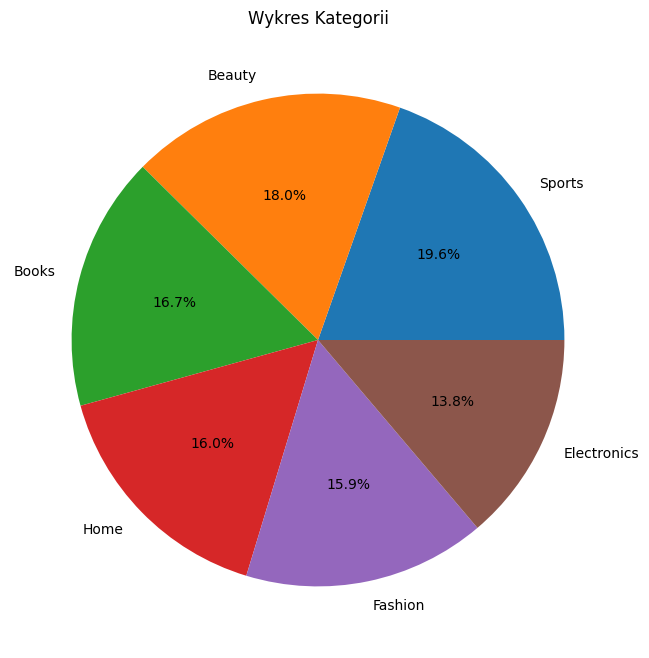

In [12]:
category = product["Category"].value_counts()
plt.figure(figsize=(8,8))
plt.pie(category.values, labels=category.index, autopct ='%1.1f%%')
plt.title("Wykres Kategorii")
plt.show()

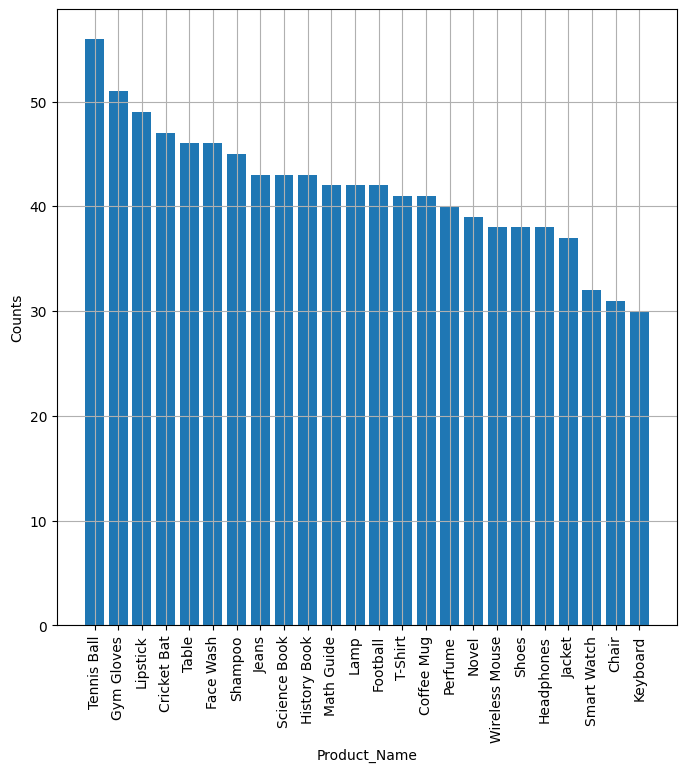

In [13]:
product_name = product["Product_Name"].value_counts()
plt.figure(figsize=(8,8))
plt.bar(product_name.index, product_name.values)
plt.xlabel("Product_Name")
plt.ylabel("Counts")
plt.xticks(rotation=90)
plt.grid()
plt.show()

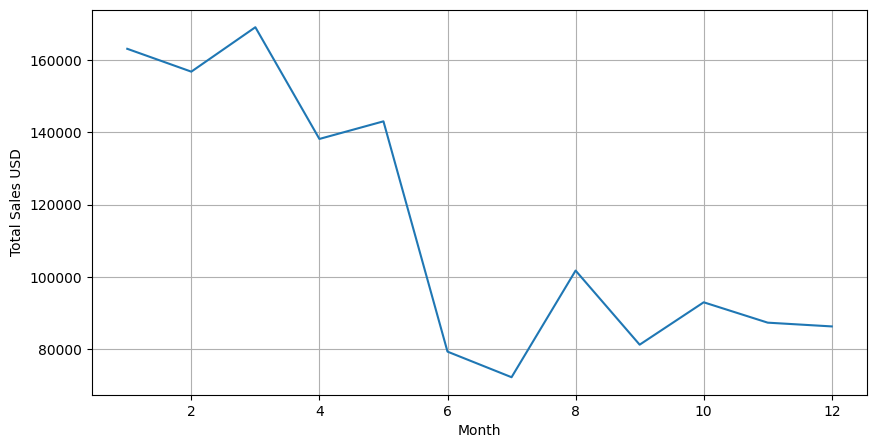

In [14]:
monthly_sales = (product.groupby(product["Order_Date"].dt.month)["Total_Sales_USD"].sum())
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index,monthly_sales.values)
plt.xlabel("Month")
plt.ylabel("Total Sales USD")
plt.grid()
plt.show()